# Money plot × Sobol × assembly — a per-halo synthesis

Three datasets, one frame:

1. The **money plot** ($Y_{200}/Y_{200}^{\rm SS}$ vs $P_{\rm hydro}/P_{\rm DMO}$ at $k\!\approx\!10.4\,h/\mathrm{Mpc}$) from `tsz_wl_calibration.ipynb`. This is a *population* statement: across CV halos, where $Y$ lands relative to self-similar predicts $P_k$ suppression.
2. The **Sobol cube** at `/mnt/home/mlee1/ceph/sobol_ss_cv/cube.npz` — the *same* ~1111 CV halos regenerated under 256 designs in the 30 astro params (cosmology fixed). This gives each halo a *trajectory* on the money plot as feedback varies.
3. Each halo's **3D assembly history** (`assembly_table.npz`) and **DMO structure** (`dmo_structure.npz`) — baryon-free identifiers (concentration, spin, $z_{\rm form}$, …) that are the same in every design.

Synthesis questions:

- (§1) How wide is the money-plot relation when it is built from *the same halos under varied feedback* rather than CV cosmic-variance?
- (§2) What fraction of a halo's $S$ scatter is feedback-driven (across designs, fixed halo) vs assembly-driven (across halos, fixed design)?
- (§3) Which **assembly properties predict a halo's susceptibility** to feedback knobs (per-halo $\partial S/\partial\theta$)?
- (§4) Does the slope/intercept/intrinsic-scatter of the money plot itself **vary with halo assembly**?

## 0. Setup — load and align the three data products

All three files are aligned 1:1 by `(sim_id, M200)` (the assembly/DMO-structure tables were built from the same `load_cv_halos()` ordering as `cube.npz`). We verify the alignment, attach per-halo features as extra axes on the `(design, halo)` cube, and build the per-design $\Delta_{\rm SS}=\log_{10}(Y_{200}/Y_{200}^{\rm SS})$ used by every section below.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

ROOT = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
cube = np.load(ROOT / 'cube.npz', allow_pickle=True)
asm  = np.load(ROOT / 'assembly_table.npz', allow_pickle=True)
dms  = np.load(ROOT / 'dmo_structure.npz', allow_pickle=True)

# Alignment check (same halo order across the three products).
for label, z in [('assembly', asm), ('dmo_structure', dms)]:
    assert np.array_equal(z['sim_id'], cube['sim_id']), f'{label}: sim_id mismatch'
    assert np.allclose(z['M200'], cube['M200']),       f'{label}: M200 mismatch'

OBS         = cube['obs']                         # (n_design, n_halo, n_obs)
OBS_NAMES   = list(cube['obs_names'])
M200        = cube['M200'].astype(float)
logM        = np.log10(M200)
SIM_ID      = cube['sim_id']
DESIGN_NORM = cube['design_norm']                 # (n_design, 30) in [0,1]
ASTRO_NAMES = list(cube['astro_names'])
n_design, n_halo, _ = OBS.shape
iY, iS, iP, iFG = (OBS_NAMES.index(k) for k in ('Y200', 'supp_k10', 'supp_prof', 'f_gas'))

SHORT = {'WindEnergyIn1e51erg': 'A_SN1', 'VariableWindVelFactor': 'A_SN2',
         'RadioFeedbackFactor': 'A_AGN1', 'RadioFeedbackReiorientationFactor': 'A_AGN2'}
PLAB = [SHORT.get(n, n) for n in ASTRO_NAMES]

# Per-halo assembly + structural features (broadcast over designs when needed).
ASM_FEATS  = {k: asm['feats'][:, j] for j, k in enumerate(asm['feat_names'])}
STR_FEATS  = {k: dms['feats'][:, j] for j, k in enumerate(dms['feat_names'])}
ALL_FEATS  = {**ASM_FEATS, **STR_FEATS, 'logM': logM}
FEAT_LABELS = {
    'c_V': r'$c_V=V_{\rm max}/V_{200}$', 'lambda': r'spin $\lambda$',
    'veldisp': r'$\sigma_v$', 'rhalf': r'$R_{1/2}/R_{200}$', 'z_form': r'$z_{\rm form}$',
    'c_core': r'core conc. $c_{\rm core}$', 'r_half': r'DMO $R_{1/2}$',
    'q_DMO': r'DMO axis $q$', 'q_DMO_in': r'DMO inner $q$',
    'logM': r'$\log_{10} M_{200}$',
}

# Per-design Δ_SS  (cosmology fixed, so c0 absorbs the Omega_b/Omega_M factor).
Y      = OBS[..., iY]
S      = OBS[..., iS]
logY   = np.where(Y > 0, np.log10(np.where(Y > 0, Y, 1.0)), np.nan)
logc0  = np.nanmean(logY - (5 / 3) * logM[None, :], axis=1)   # (n_design,)
DELTA  = logY - (logc0[:, None] + (5 / 3) * logM[None, :])    # (n_design, n_halo)

FIG = Path('money_assembly_figs'); FIG.mkdir(exist_ok=True)
def save(fig, name):
    for e in ('png', 'pdf'):
        fig.savefig(FIG / f'{name}.{e}')
    print('wrote', FIG / f'{name}.png')

print(f'designs={n_design}  halos={n_halo}  obs={OBS_NAMES}')
print(f'assembly features : {list(ASM_FEATS)}   ({asm["matched"].sum()}/{n_halo} matched)')
print(f'DMO  structure    : {list(STR_FEATS)}')
print(f'Y200       valid frac : {np.isfinite(Y).mean():.3f}')
print(f'supp_k10   valid frac : {np.isfinite(S).mean():.3f}')
print(f'Δ_SS  med ± std (across all design,halo) : {np.nanmedian(DELTA):+.3f}  {np.nanstd(DELTA):.3f}')
print(f'S     med ± std (across all design,halo) : {np.nanmedian(S):+.3f}  {np.nanstd(S):.3f}')

designs=256  halos=1111  obs=['Y200', 'T', 'S', 'P', 'f_gas', 'm_gen', 'supp_k10', 'supp_prof']
assembly features : ['c_V', 'lambda', 'veldisp', 'rhalf', 'z_form']   (1111/1111 matched)
DMO  structure    : ['c_core', 'r_half', 'q_DMO', 'q_DMO_in']
Y200       valid frac : 1.000
supp_k10   valid frac : 1.000
Δ_SS  med ± std (across all design,halo) : -0.018  0.199
S     med ± std (across all design,halo) : +0.882  0.149


## 1. Mass sets the location; feedback sets the trajectory

The CV money plot mixes three things in one cloud: halo *mass*, halo *assembly*, and the *one* feedback realization that universe happened to have. With the Sobol cube we can separate them. We'll do it in two steps so the rest of the notebook has a clean mental model.

**Question:** what does a single halo's track on $(\Delta_{\rm SS},\, S)$ look like when only the feedback knobs vary, and how does the population of those tracks depend on halo mass?

**Read the plots as:**
- *Left* — every halo collapsed to one point: its median $(\Delta_{\rm SS}, S)$ over the 256 designs, colored by mass. This is the "where do halos live" view; the mass gradient is the strongest signal in the data, and the rest of the notebook is about what's left *after* you control for it.
- *Right* — at one fixed mass bin ($13.6 < \log M_{200} < 13.9$), every halo is a short line segment showing the linear *response* of $S$ to $\Delta_{\rm SS}$ across the 256 designs (its own personal money-plot slope). Color = $z_{\rm form}$. If all the segments overlay, assembly does nothing at fixed mass. If they fan out, assembly is a hidden second axis.


wrote money_assembly_figs/money_trajectories.png


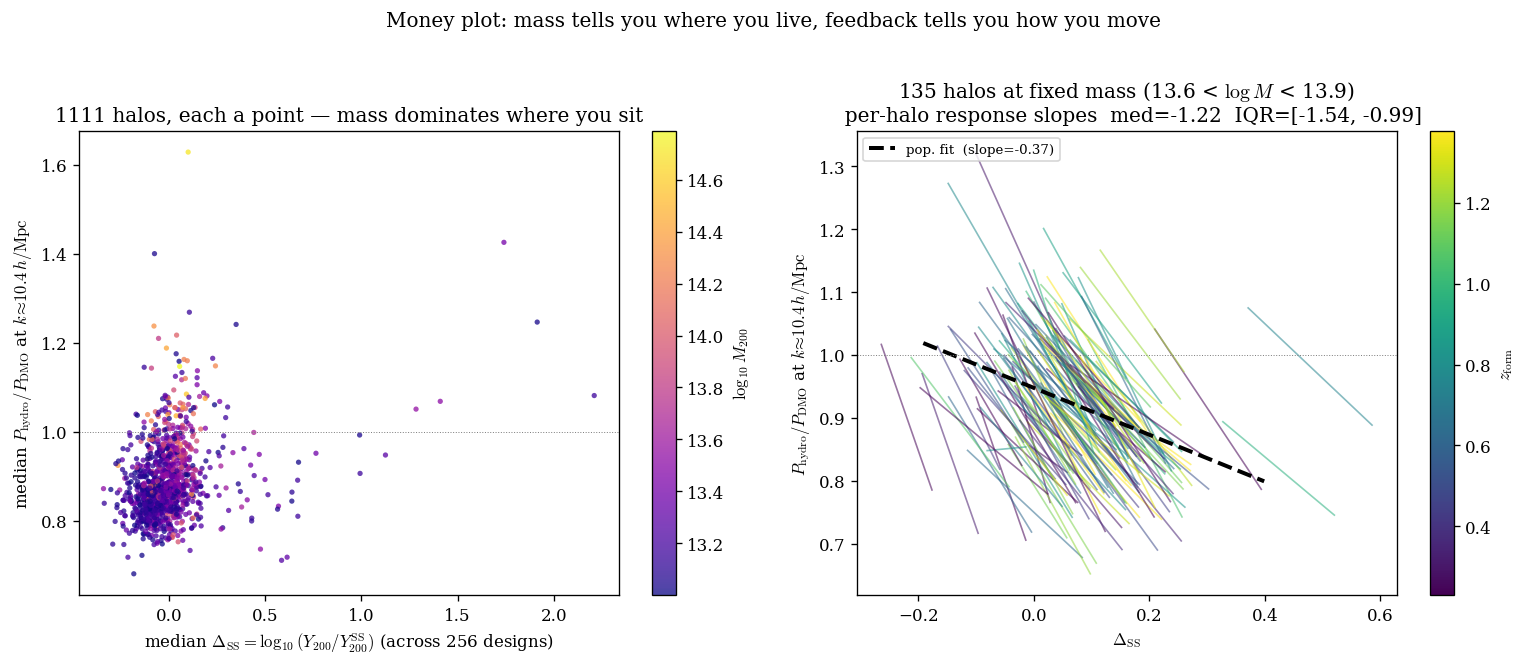

In [8]:
# Per-halo summaries over the 256 designs.
delta_med = np.nanmedian(DELTA, axis=0)        # (n_halo,)
S_med     = np.nanmedian(S,     axis=0)        # (n_halo,)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

# ---- Left: one point per halo, colored by mass ----
ax = axes[0]
ok = np.isfinite(delta_med) & np.isfinite(S_med)
sc = ax.scatter(delta_med[ok], S_med[ok], s=10, c=logM[ok], cmap='plasma', alpha=0.75,
                edgecolors='none')
fig.colorbar(sc, ax=ax, label=r'$\log_{10} M_{200}$')
ax.axhline(1.0, color='0.5', lw=0.6, ls=':')
ax.set_xlabel(r'median $\Delta_{\rm SS}=\log_{10}(Y_{200}/Y_{200}^{\rm SS})$ (across 256 designs)')
ax.set_ylabel(r'median $P_{\rm hydro}/P_{\rm DMO}$ at $k\!\approx\!10.4\,h/\mathrm{Mpc}$')
ax.set_title(f'{ok.sum()} halos, each a point — mass dominates where you sit')

# ---- Right: per-halo response slopes at fixed mass, colored by assembly ----
ax = axes[1]
mlo, mhi = 13.6, 13.9
mass_band = (logM > mlo) & (logM < mhi)
zf = ASM_FEATS['z_form']
band = np.where(mass_band & np.isfinite(zf))[0]

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=float(np.nanpercentile(zf[band], 10)),
                     vmax=float(np.nanpercentile(zf[band], 90)))

# For each halo: fit S = a + b*Δ across the 256 designs, draw a short line over
# its own Δ range so each segment is the halo's local money-plot response.
slopes = np.full(len(band), np.nan)
for i, h in enumerate(band):
    xh = DELTA[:, h]; yh = S[:, h]
    mk = np.isfinite(xh) & np.isfinite(yh)
    if mk.sum() < 50:
        continue
    b1, b0 = np.polyfit(xh[mk], yh[mk], 1)
    slopes[i] = b1
    xs = np.array([np.nanpercentile(xh[mk], 10), np.nanpercentile(xh[mk], 90)])
    ys = b0 + b1 * xs
    ax.plot(xs, ys, color=cmap(norm(zf[h])), lw=1.0, alpha=0.55)

# Population fit through all (Δ, S) samples in this mass band, for reference.
xa = DELTA[:, band].ravel(); ya = S[:, band].ravel()
mk = np.isfinite(xa) & np.isfinite(ya)
b1, b0 = np.polyfit(xa[mk], ya[mk], 1)
xs = np.linspace(np.nanpercentile(xa[mk], 1), np.nanpercentile(xa[mk], 99), 80)
ax.plot(xs, b0 + b1 * xs, color='k', lw=2.4, ls='--',
        label=f'pop. fit  (slope={b1:+.2f})')

ax.axhline(1.0, color='0.5', lw=0.6, ls=':')
ax.set_xlabel(r'$\Delta_{\rm SS}$')
ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$ at $k\!\approx\!10.4\,h/\mathrm{Mpc}$')
ax.set_title(rf'{len(band)} halos at fixed mass ({mlo} < $\log M$ < {mhi})'
             f'\n  per-halo response slopes  med={np.nanmedian(slopes):+.2f}'
             f'  IQR=[{np.nanpercentile(slopes,25):+.2f}, {np.nanpercentile(slopes,75):+.2f}]')
ax.legend(fontsize=8, loc='upper left')
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax, label=r'$z_{\rm form}$')

fig.suptitle('Money plot: mass tells you where you live, feedback tells you how you move', y=1.02)
fig.tight_layout()
save(fig, 'money_trajectories'); plt.show()


## 2. Where does the money-plot scatter come from?

The §1 trajectories made it visual: at fixed mass, *feedback* moves a halo along its own track, and *assembly* slides the tracks past each other. We now turn that into numbers.

**Question:** if you stand on the money plot and stare at the spread in $S$, how much of it is "wiggle this halo's feedback" and how much of it is "swap to a different halo at the same feedback"?

We compute two orthogonal slices of the $(d, h)$ matrix:

- $\sigma_{\rm fb}(h) = \mathrm{std}_d\, S_{d,h}$ — fix a halo, vary feedback. "Feedback susceptibility."
- $\sigma_{\rm asm}(d) = \mathrm{std}_h\, S_{d,h}$ — fix a feedback, vary halo. "Halo-to-halo (mass + assembly) scatter."

Then we redo both *after subtracting a $\log M$ trend per design*, so we can see how much of the halo-to-halo spread is just the mass dependence we already saw in §1 vs genuinely something else (= assembly).

**Read the plots as:**
- *(a)* solid histograms = raw; dashed = mass-detrended. The dashed blue is the bit we care about — assembly *beyond* mass.
- *(b)* per-halo feedback susceptibility vs $\log M$. If the red dots tilt strongly upward, susceptibility is just a mass effect.
- *(c)* per-design halo-scatter vs that design's median $S$. Tells you whether some feedback regimes amplify halo-to-halo differences (e.g. strong AGN makes the rich/poor halos diverge).

**What would kill the assembly story:** the dashed-blue histogram collapses to ~0, i.e. once you remove mass there is no halo-to-halo spread left to explain.


wrote money_assembly_figs/variance_decomposition.png


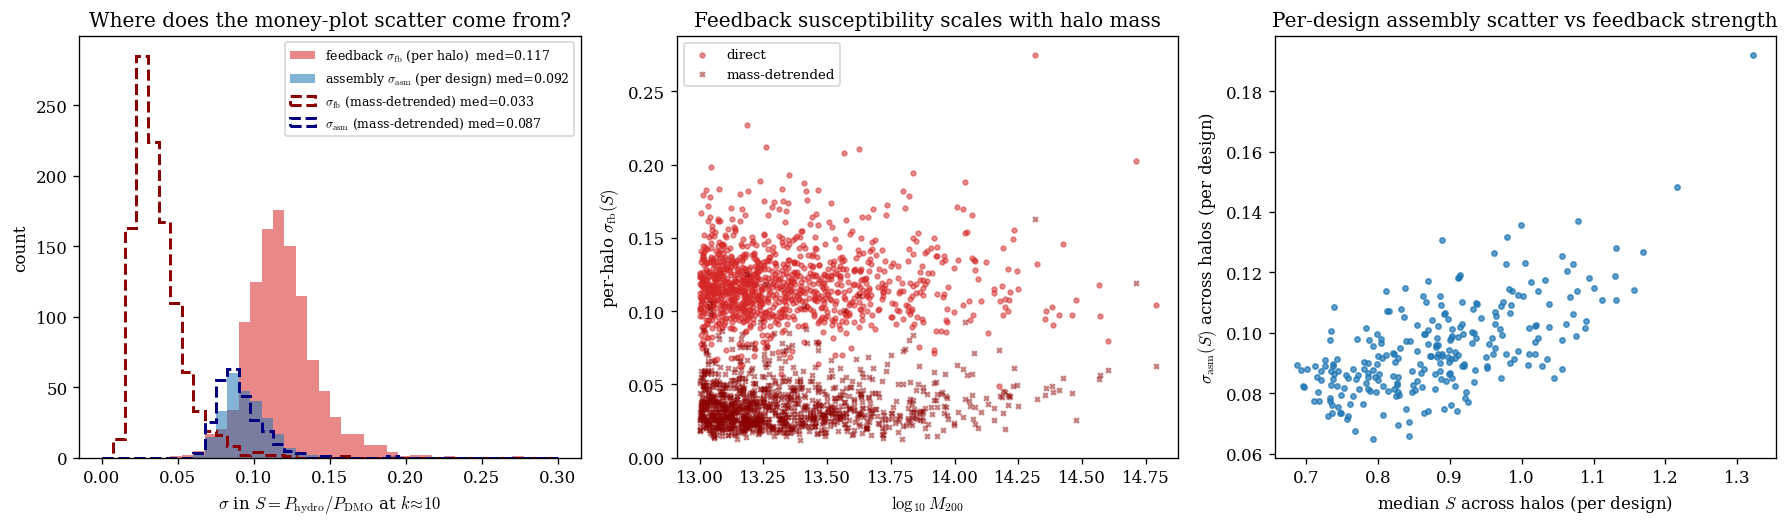


median feedback width per halo  : sigma_fb  = 0.117   (mass-detrended 0.033)
median assembly width per design: sigma_asm = 0.092   (mass-detrended 0.087)
Mass-detrending kills most of σ_asm — assembly *alone* (after the mass trend) is
a much smaller knob than feedback for the suppression S.


In [9]:
def detrend_logM(s_dh):
    out = np.full_like(s_dh, np.nan)
    for d in range(s_dh.shape[0]):
        y = s_dh[d]
        m = np.isfinite(y) & np.isfinite(logM)
        if m.sum() < 10:
            continue
        p = np.polyfit(logM[m], y[m], 1)
        out[d, m] = y[m] - np.polyval(p, logM[m])
    return out

S_dm = detrend_logM(S)

sig_fb  = np.nanstd(S,    axis=0)   # per halo  (across designs)
sig_asm = np.nanstd(S,    axis=1)   # per design (across halos)
sig_fb_dm  = np.nanstd(S_dm, axis=0)
sig_asm_dm = np.nanstd(S_dm, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) histograms — direct vs mass-detrended
ax = axes[0]
bins = np.linspace(0, 0.30, 41)
ax.hist(sig_fb,  bins=bins, alpha=0.55, color='tab:red',
        label=fr'feedback $\sigma_{{\rm fb}}$ (per halo)  med={np.nanmedian(sig_fb):.3f}')
ax.hist(sig_asm, bins=bins, alpha=0.55, color='tab:blue',
        label=fr'assembly $\sigma_{{\rm asm}}$ (per design) med={np.nanmedian(sig_asm):.3f}')
ax.hist(sig_fb_dm,  bins=bins, histtype='step', lw=1.8, color='darkred',  ls='--',
        label=fr'$\sigma_{{\rm fb}}$ (mass-detrended) med={np.nanmedian(sig_fb_dm):.3f}')
ax.hist(sig_asm_dm, bins=bins, histtype='step', lw=1.8, color='navy',     ls='--',
        label=fr'$\sigma_{{\rm asm}}$ (mass-detrended) med={np.nanmedian(sig_asm_dm):.3f}')
ax.set_xlabel(r'$\sigma$ in $S=P_{\rm hydro}/P_{\rm DMO}$ at $k\!\approx\!10$')
ax.set_ylabel('count'); ax.set_title('Where does the money-plot scatter come from?')
ax.legend(fontsize=7.5)

# (b) per-halo feedback susceptibility vs mass — is it just bigger for big halos?
ax = axes[1]
ax.scatter(logM, sig_fb, s=8, c='tab:red', alpha=0.5, label='direct')
ax.scatter(logM, sig_fb_dm, s=8, c='darkred', alpha=0.5, marker='x', label='mass-detrended')
ax.set_xlabel(r'$\log_{10} M_{200}$')
ax.set_ylabel(r'per-halo $\sigma_{\rm fb}(S)$')
ax.set_title('Feedback susceptibility scales with halo mass')
ax.legend(fontsize=8); ax.set_ylim(bottom=0)

# (c) per-design assembly scatter vs the design's median S — feedback knob trade-off
ax = axes[2]
med_S_design = np.nanmedian(S, axis=1)
ax.scatter(med_S_design, sig_asm, s=10, c='tab:blue', alpha=0.7)
ax.set_xlabel(r'median $S$ across halos (per design)')
ax.set_ylabel(r'$\sigma_{\rm asm}(S)$ across halos (per design)')
ax.set_title('Per-design assembly scatter vs feedback strength')

fig.tight_layout()
save(fig, 'variance_decomposition'); plt.show()

print(f'\nmedian feedback width per halo  : sigma_fb  = {np.nanmedian(sig_fb):.3f}'
      f'   (mass-detrended {np.nanmedian(sig_fb_dm):.3f})')
print(f'median assembly width per design: sigma_asm = {np.nanmedian(sig_asm):.3f}'
      f'   (mass-detrended {np.nanmedian(sig_asm_dm):.3f})')
print('Mass-detrending kills most of σ_asm — assembly *alone* (after the mass trend) is')
print('a much smaller knob than feedback for the suppression S.')

## 3. *Which* assembly property sets a halo's feedback response?

§2 said "some of the halo-to-halo $S$ scatter survives the mass detrend." This section asks **what halo property is responsible**, and **which feedback knob it modulates**.

For every halo $h$ we regress its 256 $S$ values on the 30 standardized knob coordinates:

$$ S_{d,h} \;=\; \sum_k \beta_{k,h}\, u_{d,k} \;+\; c_h \;+\; \varepsilon. $$

$\beta_{k,h}$ is the halo's *signed* response to knob $k$ (in units of $S$ per 1σ of the knob). The vector $\beta_h\in\mathbb{R}^{30}$ is that halo's full "feedback fingerprint"; $\sqrt{\langle\beta^2\rangle}$ collapses it to a scalar **susceptibility**. We then correlate susceptibility with every halo property we have (assembly + DMO structure + $\log M$), once raw and once after partialing out $\log M$ — the mass-controlled column is the one that matters.

**Read the plots as:**
- *(a)* susceptibility vs $\log M$ (color = $z_{\rm form}$). Confirms that bigger halos respond more; tells you whether $z_{\rm form}$ adds anything visible inside fixed-mass slices.
- *(b)* the **answer plot.** Gray bars = raw Spearman of each halo property with susceptibility; red bars = *partial* correlation given $\log M$. **Look at the red bars only.** Any nonzero red bar is an assembly handle on susceptibility that mass alone can't explain.
- *(c)* the strongest red-bar property plotted against the slope to the single most-responsive knob — the cleanest visual of the most-promising halo→knob coupling we found.

**What would kill the assembly story:** all red bars sit on top of zero.


top knobs by mean |β| across halos:
  BlackHoleRadiativeEfficiency      mean β = +0.0476   mean |β| = 0.0476
  IMFslope                          mean β = -0.0382   mean |β| = 0.0382
  A_SN1                             mean β = +0.0320   mean |β| = 0.0320
  QuasarThreshold                   mean β = -0.0307   mean |β| = 0.0307
  WindFreeTravelDensFac             mean β = +0.0257   mean |β| = 0.0257
  A_SN2                             mean β = -0.0235   mean |β| = 0.0235

per-halo linear R² (S vs all 30 knobs):  median = 0.684,  10–90%: [0.65, 0.72]
wrote money_assembly_figs/susceptibility_vs_assembly.png


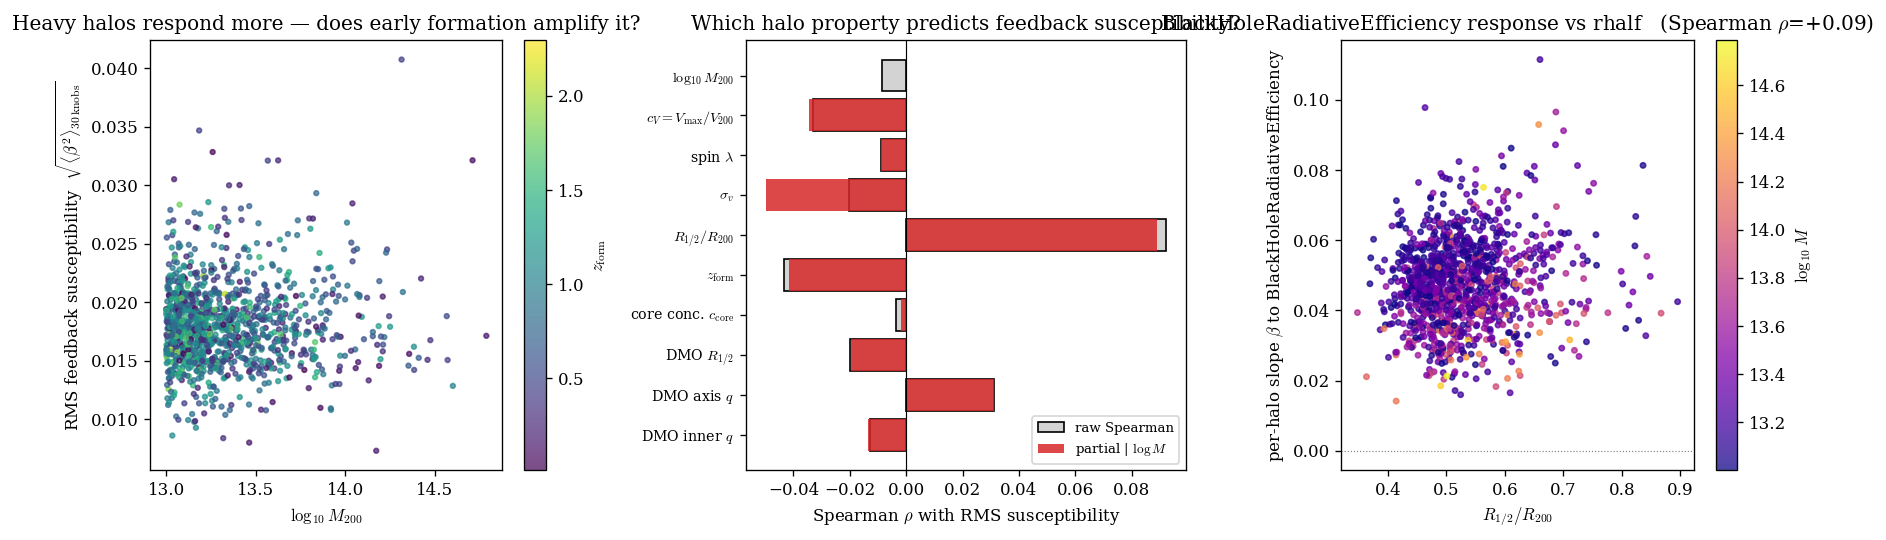

In [10]:
# Standardize the knob design once.
U = (DESIGN_NORM - DESIGN_NORM.mean(axis=0)) / (DESIGN_NORM.std(axis=0) + 1e-12)
U_with_const = np.column_stack([U, np.ones(n_design)])           # (n_design, 31)

# Solve a per-halo linear regression of S on U — vectorized via lstsq per halo.
BETA  = np.full((n_halo, len(ASTRO_NAMES)), np.nan)   # standardized slopes per halo
INTC  = np.full(n_halo, np.nan)
R2H   = np.full(n_halo, np.nan)
for h in range(n_halo):
    y = S[:, h]
    m = np.isfinite(y)
    if m.sum() < 60:
        continue
    coef, *_ = np.linalg.lstsq(U_with_const[m], y[m], rcond=None)
    BETA[h] = coef[:-1]; INTC[h] = coef[-1]
    yhat = U_with_const[m] @ coef
    ss_res = np.sum((y[m] - yhat) ** 2); ss_tot = np.sum((y[m] - y[m].mean()) ** 2) + 1e-30
    R2H[h] = 1 - ss_res / ss_tot

# Dominant knob across the population (mean |β|).
knob_order = np.argsort(-np.nanmean(np.abs(BETA), axis=0))
top_knobs  = knob_order[:6]
print('top knobs by mean |β| across halos:')
for k in top_knobs:
    mb = np.nanmean(BETA[:, k]); ab = np.nanmean(np.abs(BETA[:, k]))
    print(f'  {PLAB[k]:32s}  mean β = {mb:+.4f}   mean |β| = {ab:.4f}')
print(f'\nper-halo linear R² (S vs all 30 knobs):  median = {np.nanmedian(R2H):.3f},'
      f'  10–90%: [{np.nanpercentile(R2H,10):.2f}, {np.nanpercentile(R2H,90):.2f}]')

# Susceptibility = root-mean-square slope (rotation-invariant scalar per halo).
susc_rms = np.sqrt(np.nanmean(BETA ** 2, axis=1))

feat_order = ['logM'] + [k for k in ASM_FEATS] + [k for k in STR_FEATS]
rho_global  = np.full(len(feat_order), np.nan)
rho_partial = np.full(len(feat_order), np.nan)
for j, name in enumerate(feat_order):
    v = ALL_FEATS[name]
    ok = np.isfinite(v) & np.isfinite(susc_rms)
    if ok.sum() < 30:
        continue
    rho_global[j] = spearmanr(v[ok], susc_rms[ok]).correlation
    # mass-controlled partial: residualize susceptibility & feature on logM (linear).
    if name == 'logM':
        continue
    pA = np.polyfit(logM[ok], susc_rms[ok], 1)
    pB = np.polyfit(logM[ok], v[ok], 1)
    rA = susc_rms[ok] - np.polyval(pA, logM[ok])
    rB = v[ok]        - np.polyval(pB, logM[ok])
    rho_partial[j] = spearmanr(rA, rB).correlation

# Plot — susceptibility vs assembly + the correlation bar chart.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

ax = axes[0]
ax.scatter(logM, susc_rms, s=8, c=ASM_FEATS['z_form'], cmap='viridis', alpha=0.7)
ax.set_xlabel(r'$\log_{10} M_{200}$')
ax.set_ylabel(r'RMS feedback susceptibility  $\sqrt{\langle\beta^2\rangle_{30\,\rm knobs}}$')
cb = fig.colorbar(ax.collections[0], ax=ax, label=r'$z_{\rm form}$')
ax.set_title('Heavy halos respond more — does early formation amplify it?')

ax = axes[1]
labels = [FEAT_LABELS.get(n, n) for n in feat_order]
ypos = np.arange(len(feat_order))
ax.barh(ypos, rho_global,  color='lightgray', edgecolor='k', label='raw Spearman')
ax.barh(ypos, rho_partial, color='tab:red', alpha=0.85, label=r'partial | $\log M$')
ax.axvline(0, color='k', lw=0.7)
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel(r'Spearman $\rho$ with RMS susceptibility')
ax.set_title('Which halo property predicts feedback susceptibility?')
ax.legend(fontsize=8, loc='best')

# Per-halo slope to the dominant knob (top_knobs[0]) vs the most-correlated assembly feature.
best_feat_idx = int(np.nanargmax(np.abs(rho_partial[1:])) + 1)   # skip logM
best_feat = feat_order[best_feat_idx]
knob = int(top_knobs[0])
ax = axes[2]
v = ALL_FEATS[best_feat]
b = BETA[:, knob]
ok = np.isfinite(v) & np.isfinite(b)
ax.scatter(v[ok], b[ok], s=10, c=logM[ok], cmap='plasma', alpha=0.75)
ax.axhline(0, color='0.5', lw=0.7, ls=':')
ax.set_xlabel(FEAT_LABELS.get(best_feat, best_feat))
ax.set_ylabel(rf'per-halo slope $\beta$ to {PLAB[knob]}')
rho = spearmanr(v[ok], b[ok]).correlation
ax.set_title(f'{PLAB[knob]} response vs {best_feat}   (Spearman $\\rho$={rho:+.2f})')
fig.colorbar(ax.collections[0], ax=ax, label=r'$\log_{10} M$')

fig.tight_layout()
save(fig, 'susceptibility_vs_assembly'); plt.show()

## 4. Does the money-plot *calibration* itself depend on assembly?

§2–3 worked on the *width* of each halo's trajectory. This section asks whether assembly shifts the trajectories' **shape**: the slope $\alpha$, zero-point $\beta$, and intrinsic scatter $\sigma_{\rm int}$ of the money-plot relation that `fig_money` fits in `tsz_wl_calibration.ipynb`.

We split the halos into low/mid/high tertiles of an assembly proxy and re-fit the money-plot MLE *inside each tertile, separately at every Sobol design*. That gives 256 fits per tertile — enough to compare distributions, not just point estimates.

**Read each panel as:** *x*-axis = tertile, *y*-axis = fit parameter. The colored point is the median across the 256 designs, the bar is the 16–84% spread; the gray band is the same statistic for the **full sample** (the calibration you'd get if you ignored assembly). Annotations report the shift of each tertile relative to the full-sample median in units of the full-sample design-to-design width — a $|\Delta|>1$ is "this tertile has systematically different calibration than the all-halo fit, beyond design variation."

- **Slope $\alpha$ / zero-point $\beta$** — if the colored points sit inside the gray band, the *shape* of the money plot is assembly-universal. If they tilt monotonically with the tertile, you're seeing a hidden axis in the calibration.
- **Intrinsic scatter $\sigma_{\rm int}$** — the headline panel. If within-tertile $\sigma_{\rm int}$ is systematically *below* the full-sample band, what the global money plot called "irreducible feedback floor" was partly assembly noise that goes away when you split.

Flip `TERTILE_BY` to `c_V`, `c_core`, or `lambda` to repeat the test with another assembly handle.


wrote money_assembly_figs/money_calibration_by_z_form.png


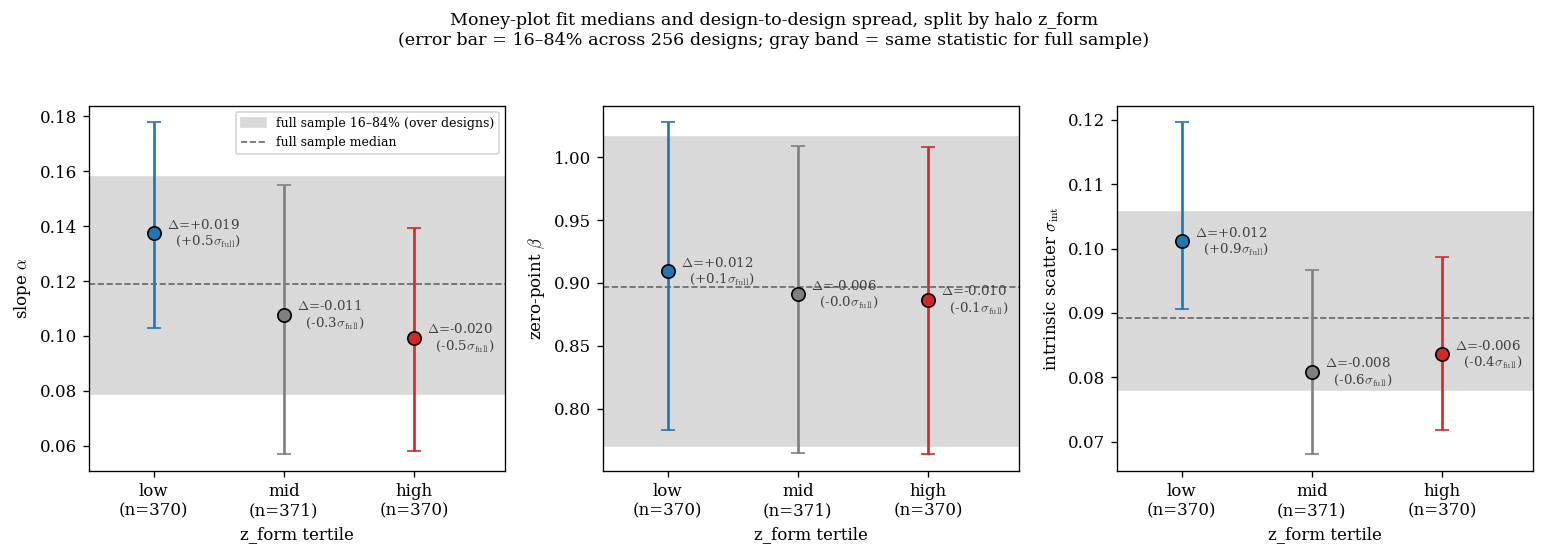

Within-tertile vs full-sample medians of the per-design money-plot fit (z_form)

[alpha] full-sample median=+0.119  (16-84% width over designs = 0.079)
   low  median=+0.137   Δ vs full=+0.019   (+0.5σ_full)
   mid  median=+0.108   Δ vs full=-0.011   (-0.3σ_full)
   high median=+0.099   Δ vs full=-0.020   (-0.5σ_full)

[beta ] full-sample median=+0.897  (16-84% width over designs = 0.246)
   low  median=+0.909   Δ vs full=+0.012   (+0.1σ_full)
   mid  median=+0.891   Δ vs full=-0.006   (-0.0σ_full)
   high median=+0.887   Δ vs full=-0.010   (-0.1σ_full)

[sigma] full-sample median=+0.089  (16-84% width over designs = 0.028)
   low  median=+0.101   Δ vs full=+0.012   (+0.9σ_full)
   mid  median=+0.081   Δ vs full=-0.008   (-0.6σ_full)
   high median=+0.084   Δ vs full=-0.006   (-0.4σ_full)

Rule of thumb: a Δ tagged "shifted >1σ_full" means the tertile-specific calibration
disagrees with the all-halo one by more than the design-to-design noise of the full fit
— i.e. assembly is a real, 

In [12]:
from scipy.optimize import minimize

def fit_design_in_subset(d, halo_mask):
    x = DELTA[d][halo_mask]; y = S[d][halo_mask]
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 20:
        return None
    x, y = x[m], y[m]
    piv = float(np.median(x)); xx = x - piv
    a0, b0 = np.polyfit(xx, y, 1); s0 = float(np.std(y - (a0 * xx + b0))) + 1e-6
    def nll(th):
        a, b, ls = th; s2 = np.exp(2 * ls); r = y - (a * xx + b)
        return 0.5 * np.sum(np.log(2 * np.pi * s2) + r * r / s2)
    res = minimize(nll, [a0, b0, np.log(s0)], method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-7})
    a, b, ls = res.x
    return dict(alpha=float(a), beta=float(b), sigma=float(np.exp(ls)), n=int(m.sum()))

TERTILE_BY = 'z_form'   # easy to flip to 'c_V' / 'c_core' / 'lambda'
v = ALL_FEATS[TERTILE_BY]
ok = np.isfinite(v)
edges = np.nanpercentile(v[ok], [0, 33.33, 66.67, 100])
bins = np.digitize(v, edges[1:-1])               # 0,1,2; NaNs land in 0 — filter with ok
tert_masks = [ok & (bins == k) for k in range(3)]
tert_short = ['low', 'mid', 'high']
tert_labels = [f'{s}\n(n={tm.sum()})' for s, tm in zip(tert_short, tert_masks)]

params_by_tert = []
for tm in tert_masks:
    rows = [fit_design_in_subset(d, tm) for d in range(n_design)]
    params_by_tert.append(pd.DataFrame([r for r in rows if r is not None]))
full_mask = ok
rows_full = [fit_design_in_subset(d, full_mask) for d in range(n_design)]
params_full = pd.DataFrame([r for r in rows_full if r is not None])

# Tertile-vs-quantity error bars; gray band = full-sample 16–84% across designs.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
panels = [('alpha', r'slope $\alpha$'),
          ('beta',  r'zero-point $\beta$'),
          ('sigma', r'intrinsic scatter $\sigma_{\rm int}$')]
colors = ['#1f77b4', '#7f7f7f', '#d62728']

x_pos = np.arange(3)
for ax, (key, ttl) in zip(axes, panels):
    # Full-sample reference band & median across the 256 designs.
    full_med = params_full[key].median()
    full_lo  = params_full[key].quantile(0.16)
    full_hi  = params_full[key].quantile(0.84)
    full_w   = max(full_hi - full_lo, 1e-9)
    ax.axhspan(full_lo, full_hi, color='0.85', zorder=0,
               label='full sample 16–84% (over designs)')
    ax.axhline(full_med, color='0.4', lw=1.0, ls='--', zorder=1, label='full sample median')

    # Tertile medians + 16–84% error bars.
    meds  = np.array([df[key].median()         for df in params_by_tert])
    los   = np.array([df[key].quantile(0.16)   for df in params_by_tert])
    his   = np.array([df[key].quantile(0.84)   for df in params_by_tert])
    yerr  = np.vstack([meds - los, his - meds])
    for xp, m, e_lo, e_hi, c in zip(x_pos, meds, yerr[0], yerr[1], colors):
        ax.errorbar(xp, m, yerr=[[e_lo], [e_hi]], fmt='o', ms=8, mec='k', mfc=c,
                    ecolor=c, elinewidth=1.6, capsize=4, zorder=3)
        # Shift relative to full-sample median, in units of the full-sample design-to-design width.
        z = (m - full_med) / (0.5 * full_w)
        ax.annotate(f'$\\Delta$={m-full_med:+.3f}\n  ({z:+.1f}$\\sigma_{{\\rm full}}$)',
                    (xp, m), xytext=(8, 0), textcoords='offset points',
                    fontsize=8, va='center',
                    color='darkred' if abs(z) >= 1 else '0.25')

    ax.set_xticks(x_pos); ax.set_xticklabels(tert_labels)
    ax.set_xlabel(f'{TERTILE_BY} tertile')
    ax.set_ylabel(ttl)
    ax.set_xlim(-0.5, 2.7)
    if key == 'alpha':
        ax.legend(fontsize=7.5, loc='best')

fig.suptitle(
    f'Money-plot fit medians and design-to-design spread, split by halo {TERTILE_BY}\n'
    f'(error bar = 16–84% across 256 designs; gray band = same statistic for full sample)',
    y=1.04, fontsize=10.5)
fig.tight_layout()
save(fig, f'money_calibration_by_{TERTILE_BY}'); plt.show()

print('=' * 72)
print(f'Within-tertile vs full-sample medians of the per-design money-plot fit ({TERTILE_BY})')
print('=' * 72)
for key, ttl in panels:
    full_med = params_full[key].median()
    full_w   = params_full[key].quantile(0.84) - params_full[key].quantile(0.16)
    print(f'\n[{key:5s}] full-sample median={full_med:+.3f}  (16-84% width over designs = {full_w:.3f})')
    for s, df in zip(tert_short, params_by_tert):
        m = df[key].median()
        z = (m - full_med) / max(0.5 * full_w, 1e-9)
        flag = '  <-- shifted >1σ_full' if abs(z) >= 1 else ''
        print(f'   {s:4s} median={m:+.3f}   Δ vs full={m-full_med:+.3f}   ({z:+.1f}σ_full){flag}')
print('\nRule of thumb: a Δ tagged "shifted >1σ_full" means the tertile-specific calibration')
print('disagrees with the all-halo one by more than the design-to-design noise of the full fit')
print('— i.e. assembly is a real, hidden axis of the money-plot relation.')
